In [1]:
%matplotlib widget
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffSPH.dataLoader import *
from diffSPH.plotting import visualizeParticles, updatePlot

In [2]:
folders = [
        #   '/home/winchenbach/dev/diffSPH16K/data/compressible/circularRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/dualRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/pressureDensity/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/quadRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/velocity/',

        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/both/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/domain/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/noBoundary/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/obstacle/',
         #   '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/TGV/',

        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both/'
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/domain/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/noBoundary/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/obstacle/',
         #   '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/TGV/',

        #    '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible2/freeSlipTGV/data/',
        #    '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible2/noSlipTGV/data/',
        # '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlipv2/data/',
        '/home/winchenbach/dev/diffSPH_public/simulationScripts/data/'
]

In [3]:
configuration = DataConfiguration(
    frameDistance=1,
    frameSpacing=1,
    maxRollout=1,
    historyLength=1,
    skipInitialFrames=0,
    cutoff=0
)

processed = []

for folder in folders:
    p = processFolder(folder, configuration)
    processed.extend(p)
# processed = processFolder(folders[0], configuration)

for file in processed:
    print(f'File: {file["fileName"]}, FrameCount: {len(file["frames"])}, Samples: {len(file["samples"])}, Style: {file["style"]}, Number of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')


File: /home/winchenbach/dev/diffSPH_public/simulationScripts/data//boundedRandomFlow_4_2_0.5_2_True_perlin_45906734_without_9216_2025-08-19_13-59-39.h5, FrameCount: 3999, Samples: 3999, Style: diffSPH, Number of samples: 3999, first sample: 000001, last sample: 003999


In [4]:
dataset, datasetLoader = getDataLoader(processed, 4, shuffle = True)
datasetIter = iter(datasetLoader)

nextData = next(datasetIter)
print(f'Next data: {nextData}')

# nextData = [0, 16, 64, 98]
# nextData = [9000]

Next data: [1509, 3251, 2891, 2732]


In [5]:
import ipywidgets

dropdownFiles = ipywidgets.Dropdown(
    options=[f['fileName'] for f in processed],
    description='Files:',
    disabled=False,
    style={'description_width': 'initial'},
    layout=ipywidgets.Layout(width='50%'),
    value=processed[0]['fileName']  # Default value
)
frameSlider = ipywidgets.IntSlider(
    value=0,
    min=0,
    max=len(processed[0]['frames']) - 1,
    step=1,
    description='Frame:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=ipywidgets.Layout(width='50%')
)

def updatePlots(plots, processed, frame):
    priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
        dataset, [(processed['fileName'],'%06d'%frame)], configuration, device = 'cuda', dtype = torch.float32,
        augmentAngle = False,
    )
    # s = 1

    updatePlot(plots[0], currentState, quantity=currentState.densities, domain = domains[0], markerSize = s)
    updatePlot(plots[1], currentState, quantity=currentState.internalEnergies if isinstance(currentState, CompressibleSPHState) else currentState.velocities, domain = domains[0], markerSize = s)
    updatePlot(plots[2], currentState, quantity=currentState.velocities, domain = domains[0], markerSize = s)
    updatePlot(plots[3], currentState, quantity=currentState.UIDs, domain = domains[0], markerSize = s)
    
    fig.suptitle(f'File: {processed["fileName"].split("/")[-1]}, Frame: {processed["frames"][frame]}, Samples: {len(processed["samples"])}, Style: {processed["style"]}, \nNumber of samples: {len(processed["samples"])}, first sample: {processed["samples"][0]}, last sample: {processed["samples"][-1]}')


def updatePlotFromDropdown(change):
    if change['new'] is not None:
        fileIndex = [f['fileName'] for f in processed].index(change['new'])
        frames = processed[fileIndex]['frames']

        priorFrames = int(frameSlider.max)
        newValue = np.clip(int(frameSlider.value / priorFrames * (len(frames) - 1)), 0, len(frames) - 1)
        frameSlider.max = len(frames) - 1
        frameSlider.value = newValue
        fig.suptitle(f'File: {change["new"].split("/")[-1]}, Frame: {frames[0]}, Samples: {len(processed[fileIndex]["samples"])}, Style: {processed[fileIndex]["style"]}, \nNumber of samples: {len(processed[fileIndex]["samples"])}, first sample: {processed[fileIndex]["samples"][0]}, last sample: {processed[fileIndex]["samples"][-1]}')
        updatePlots(plots, processed[fileIndex], frame=frameSlider.value)


def updatePlotFromSlider(change):
    if change['new'] is not None:
        fileIndex = [f['fileName'] for f in processed].index(dropdownFiles.value)
        updatePlots(plots, processed[fileIndex], frame=change['new'])


dropdownFiles.observe(updatePlotFromDropdown, names='value')
frameSlider.observe(updatePlotFromSlider, names='value')


Dropdown(description='Files:', layout=Layout(width='50%'), options=('/home/winchenbach/dev/diffSPH_public/simu…

IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='50%'), max=3998, style=…

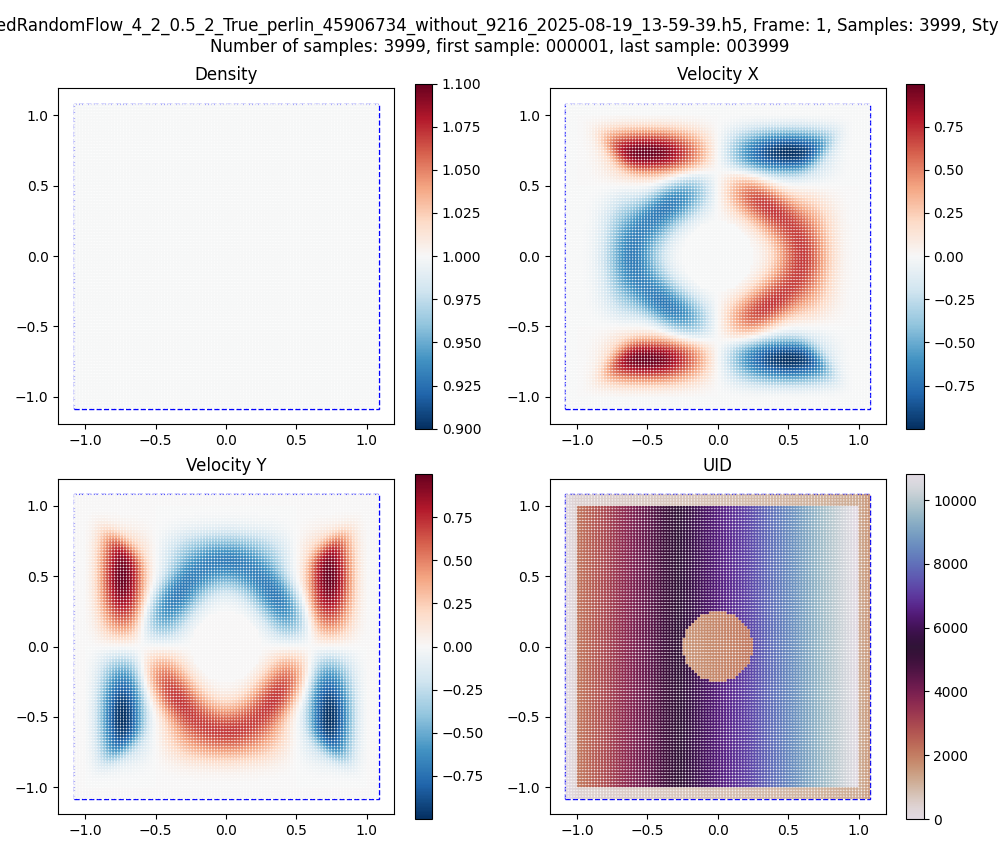

In [6]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, [(processed[0]['fileName'],'%06d'%0)], configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

fig, axis = plt.subplots(2, 2, figsize=(10, 8.5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()

s = 1.5

densityPlot = visualizeParticles(fig, axes[0],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.densities,
                            which = 'both',
                            mapping = 'L2',
                            cmap = 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Density')
energyPlot = visualizeParticles(fig, axes[1],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.internalEnergies if isinstance(currentState, CompressibleSPHState) else currentState.velocities,
                            which = 'both',
                            mapping = '.x',
                            cmap = 'viridis' if isinstance(currentState, CompressibleSPHState) else 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Internal Energy' if isinstance(currentState, CompressibleSPHState) else 'Velocity X')
velocityPlot = visualizeParticles(fig, axes[2],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.velocities,
                            which = 'both',
                            mapping = 'L2' if isinstance(currentState, CompressibleSPHState) else '.y',
                            cmap = 'turbo' if isinstance(currentState, CompressibleSPHState) else 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Velocity' if isinstance(currentState, CompressibleSPHState) else 'Velocity Y')
UIDPlot = visualizeParticles(fig, axes[3],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.UIDs,
                            which = 'both',
                            mapping = 'L2',
                            cmap = 'twilight_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'UID')


fig.suptitle(f'File: {processed[0]["fileName"].split("/")[-1]}, Frame: {processed[0]["frames"][0]}, Samples: {len(processed[0]["samples"])}, Style: {processed[0]["style"]}, \nNumber of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')
plots = [densityPlot, energyPlot, velocityPlot, UIDPlot]

fig.tight_layout()

display(dropdownFiles)
display(frameSlider)

In [7]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
        dataset, [(dropdownFiles.value,'%06d'% frameSlider.value)], configuration, device = 'cuda', dtype = torch.float32,
        augmentAngle = False,
    )

In [8]:
from diffSPH.util import ParticleSet

In [9]:
currentState.boundaryDistances.max()

tensor(0.1593, device='cuda:0')

In [11]:
print(dir(currentState))

print(dir(WeaklyCompressibleState))

['UIDs', '__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__slots__', '__str__', '__subclasshook__', 'batches', 'boundaryDistances', 'boundaryIndices', 'boundaryNormals', 'densities', 'dt', 'key', 'kinds', 'masses', 'materials', 'numParticles', 'positions', 'rigidBodies', 'supports', 'time', 'timestep', 'velocities']
['A', 'B', 'UIDcounter', 'UIDs', '__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__'

In [28]:
from diffSPH.schemes.states.wcsph import WeaklyCompressibleState
from diffSPH.enums import *
from diffSPH.simple import *
from diffSPH.rigidBody import buildRigidBody
from diffSPH.schemes.initializers import updateBodyParticlesWCSPH
import copy

def convertConfigKey(currentValue, newValue):
    if currentValue is None:
        return newValue
    
    elif isinstance(currentValue, torch.Tensor):
        return torch.tensor(newValue, device=currentValue.device, dtype=currentValue.dtype)
    elif isinstance(currentValue, dict):
        return {k: convertConfigKey(currentValue[k] if k in currentValue else None, newValue[k]) for k in newValue}
    elif isinstance(currentValue, DomainDescription):
        # print(f'Converting DomainDescription from {currentValue} to {newValue}')
        return DomainDescription(
            min=torch.tensor(newValue['min'], device=currentValue.min.device, dtype=currentValue.min.dtype),
            max=torch.tensor(newValue['max'], device=currentValue.max.device, dtype=currentValue.max.dtype),
            dim=newValue['dim'],
            periodic=torch.tensor(newValue['periodic'], device=currentValue.periodic.device, dtype=torch.bool)
        )
    elif isinstance(currentValue, Enum):
        return [e for e in type(currentValue) if e.value == newValue][0] if newValue is not None else None
    else:
        return type(currentValue)(newValue) if newValue is not None else None

def stateToState(currentState, currentConfig, batch = 0):
    """
    Converts the current state to a WeaklyCompressibleState.
    This is useful for resuming simulations or for compatibility with different state types.
    """

    state = WeaklyCompressibleState(
        positions = currentState.positions[currentState.batches == batch],
        supports = currentState.supports[currentState.batches == batch],
        masses = currentState.masses[currentState.batches == batch],
        densities = currentState.densities[currentState.batches == batch],
        velocities = currentState.velocities[currentState.batches == batch],

        pressures = torch.zeros_like(currentState.densities[currentState.batches == batch], device=currentState.densities.device, dtype=currentState.densities.dtype),
        soundspeeds= torch.ones_like(currentState.densities[currentState.batches == batch], device=currentState.densities.device, dtype=currentState.densities.dtype) * currentConfig['fluid']['c_s'],

        kinds = currentState.kinds[currentState.batches == batch],
        materials = currentState.materials[currentState.batches == batch],
        UIDs = currentState.UIDs[currentState.batches == batch],

        UIDcounter = currentState.UIDs[currentState.batches == batch].max(),

        ghostIndices = currentState.boundaryIndices[currentState.batches == batch],
        ghostOffsets = currentState.boundaryNormals[currentState.batches == batch] * currentState.boundaryDistances[currentState.batches == batch][:,None] * 2
    )

    caseName = configs[0]['attributes']['caseName'] if 'caseName' in configs[0]['attributes'] else 'default'


    kernel = [k for k in KernelType if k.value == configs[0]['kernel']][0] if configs[0]['kernel'] is not None else None
    scheme = [s for s in SimulationScheme if s.value == configs[0]['scheme']][0] if configs[0]['scheme'] is not None else None
    integrationScheme = [i for i in IntegrationSchemeType if i.value == configs[0]['integrationScheme']][0] if configs[0]['integrationScheme'] is not None else None
    targetNeighbors = configs[0]['targetNeighbors'] if configs[0]['targetNeighbors'] is not None else n_h_to_nH(4, domains[0].dim)


    device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
    dtype = torch.float32

    domain = DomainDescription(
        min = torch.tensor(domains[0].min, device=device, dtype=dtype),
        max = torch.tensor(domains[0].max, device=device, dtype=dtype),
        dim = domains[0].dim,
        periodic = torch.tensor(domains[0].periodic, device=device, dtype=torch.bool)
    )

    # kernel = KernelType.Wendland4
    # scheme = SimulationScheme.DeltaSPH
    # integrationScheme = IntegrationSchemeType.symplecticEuler

    device = currentState.positions.device if hasattr(currentState, 'positions') else torch.device('cpu')
    dtype = currentState.positions.dtype if hasattr(currentState, 'positions') else torch.float32
    
    # device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
    # dtype = torch.float32

    wrappedKernel = kernel
    simulator, SimulationSystem, config, integrator = getSimulationScheme(
        scheme, kernel, integrationScheme, 
        1.0, targetNeighbors, domain)

    for key in configs[0].keys():
        config[key] = convertConfigKey(config[key] if key in config else None, configs[0][key])


    rigidBodyIDs = torch.unique(state.materials[state.kinds == 1]).cpu().numpy()
    # print(rigidBodyIDs)
    rigidBodies = []
    for id in rigidBodyIDs:
        # print('Processing rigid body', id)
        rigidBody = buildRigidBody(state, config, id)
        if(rigidBody is not None):
            rigidBodies.append(rigidBody)


    for rigidBody in rigidBodies:
        state = updateBodyParticlesWCSPH(state, rigidBody)

    config['rigidBodies'] = rigidBodies
    config['caseName'] = caseName

    particleSystem = SimulationSystem(config['domain'], None, 0., copy.deepcopy(state), 'momentum', None, rigidBodies = config['rigidBodies'], regions = config['regions'], config = config)

    dt = configs[0]['dt'] if 'dt' in configs[0] else 0.01
    return state, particleSystem, config, domain, wrappedKernel, simulator, SimulationSystem, integrator, dt

In [31]:
state, particleSystem, config, domain, wrappedKernel, simulator, SimulationSystem, integrator, dt = stateToState(currentState, configs[0], batch=0)

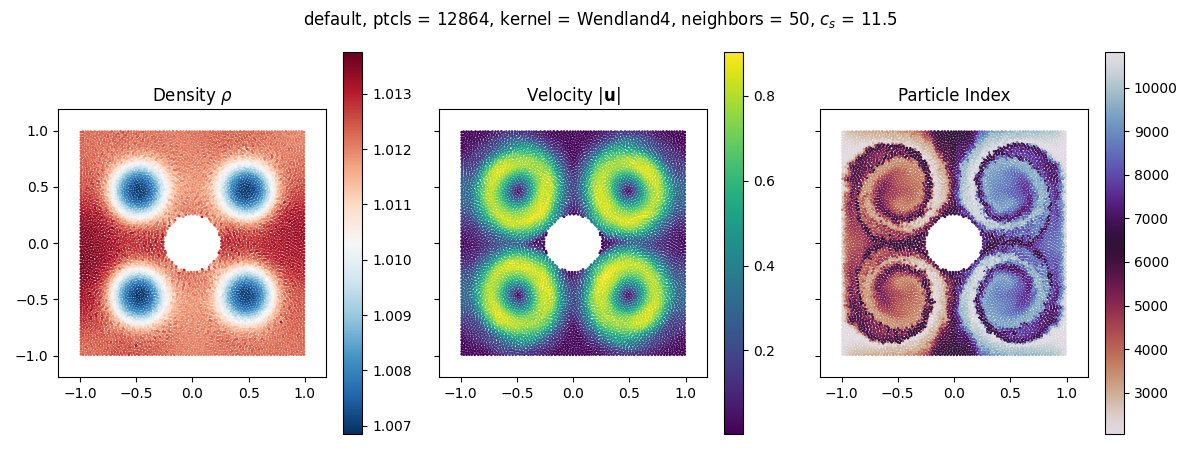

In [32]:
from tqdm import TqdmExperimentalWarning
import warnings
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
import math

fig, axis = plt.subplots(1, 3, figsize=(12, 4.5), squeeze=False, sharex=True, sharey=True)

markerSize = 1
fluidParticles = particleSystem.systemState
densityPlot = visualizeParticles(fig, axis[0,0], particles = fluidParticles, quantity = fluidParticles.densities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'RdBu_r', title='Density $\\rho$', markerSize = markerSize)
velocityPlot = visualizeParticles(fig, axis[0,1], particles = fluidParticles, quantity = fluidParticles.velocities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'viridis', title='Velocity $|\\mathbf{u}|$', markerSize = markerSize, mapping = 'L2')
UIDPlot = visualizeParticles(fig, axis[0,2], particles = fluidParticles, quantity = fluidParticles.UIDs, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'twilight_r', title='Particle Index', markerSize = markerSize)

fig.suptitle(f'{config["caseName"]}, ptcls = {state.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}')
fig.tight_layout()

In [47]:
for i in (tq:=tqdm(range(timesteps))):
    particleSystem, currentState, updates = integrator.function(particleSystem, targetDt, simulator, config, priorStep = particleSystem.priorStep)
    particleSystem.priorStep = [updates[-1], currentState[-1]]
    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlot, particleSystem.systemState, particleSystem.systemState.densities)
        updatePlot(velocityPlot, particleSystem.systemState, particleSystem.systemState.velocities)
        updatePlot(UIDPlot, particleSystem.systemState, particleSystem.systemState.UIDs)
        
        fig.canvas.draw()
        fig.canvas.flush_events()

  0%|          | 0/3999 [00:00<?, ?it/s]

KeyboardInterrupt: 